# H&M Personalized Fashion Recommendations

This recommender uses a two-stage retrieval & ranking architecture

**Stage 1 (Retrieval):** Generate 50~ high-probablity recommendations per user using multi-source heuristics (Collaborative Filtering, Demographic Trends, and Seasonality)

**Stage 2 (Ranking):** Use a Gradient Boosted Decesion Tree (LightGBM Ranker) to precisely re-order those recommendations based on behavioral features

**Key Challenge**: Scaling inference to 1.3M customers within RAM constraints

## Environment, Downcasting, and Data Exploration

Data Setup:
The dataset used in this project is the H&M Personalized Fashion Recommendations dataset from Kaggle.

Download the data from Kaggle (https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations).

Extract the files into a folder named data/ in the root directory.

Ensure the structure looks like: data/transactions_train.csv, data/customers.csv, etc.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import lightgbm as lgb
import shap
from tqdm import tqdm
import gc

In [2]:
path = r"data/"
train = pd.read_csv(path + "transactions_train.csv", dtype={'article_id': str})
customers = pd.read_csv(path + "customers.csv")
articles = pd.read_csv(path + "articles.csv", dtype={'article_id': str})
sample_submission = pd.read_csv(path + "sample_submission.csv")
# goal is to predict article_id

In [3]:
# Downcasting dataframes to try and save ram space
def downcast_df(df):
    exclude = ['article_id', 'customer_id'] # Must be kept as string to preserve leading zeroes
    for col in df.columns:
        if col in exclude:
            continue # Skip these columns entirely
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        if df[col].dtype == 'int64':
            df[col] = df[col].astype('int32') # Use unsigned int for IDs to save space
        elif df[col].dtype == 'object' and df[col].nunique() < 100: # If a string column has few unique values, make it a category
            df[col] = df[col].astype('category')
    return df

train = downcast_df(train)
articles = downcast_df(articles)
customers = downcast_df(customers)

In [4]:
train.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687004,0.016932,2


In [5]:
train.shape

(31788324, 5)

In [6]:
articles.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,0108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,0108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,0108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,0110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,0110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [7]:
customers.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


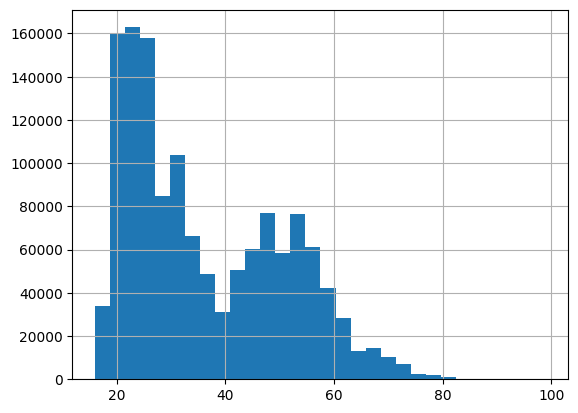

In [8]:
customers['age'].hist(bins=30)
plt.show()

In [9]:
customers['club_member_status'].value_counts()

club_member_status
ACTIVE        1272491
PRE-CREATE      92960
LEFT CLUB         467
Name: count, dtype: int64

In [10]:
for x in ['FN', 'Active', 'club_member_status', 'fashion_news_frequency']:
    print(customers[x].value_counts())
    print('')
print("Missing Values:")
print(customers.isnull().sum().sort_values(ascending=False))

FN
1.0    476930
Name: count, dtype: int64

Active
1.0    464404
Name: count, dtype: int64

club_member_status
ACTIVE        1272491
PRE-CREATE      92960
LEFT CLUB         467
Name: count, dtype: int64

fashion_news_frequency
NONE         877711
Regularly    477416
Monthly         842
Name: count, dtype: int64

Missing Values:
Active                    907576
FN                        895050
fashion_news_frequency     16011
age                        15861
club_member_status          6062
customer_id                    0
postal_code                    0
dtype: int64


In [11]:
articles['prod_name'].unique()

array(['Strap top', 'Strap top (1)', 'OP T-shirt (Idro)', ...,
       'Cartwheel dress', 'CLAIRE HAIR CLAW', 'Lounge dress'],
      shape=(45875,), dtype=object)

In [12]:
articles['product_group_name'].unique()

['Garment Upper body', 'Underwear', 'Socks & Tights', 'Garment Lower body', 'Accessories', ..., 'Bags', 'Furniture', 'Garment and Shoe care', 'Fun', 'Stationery']
Length: 19
Categories (19, object): ['Accessories', 'Bags', 'Cosmetic', 'Fun', ..., 'Swimwear', 'Underwear', 'Underwear/nightwear', 'Unknown']

In [13]:
# Finding the top 10 most sold items
print(train['article_id'].value_counts().head(10))

article_id
0706016001    50287
0706016002    35043
0372860001    31718
0610776002    30199
0759871002    26329
0464297007    25025
0372860002    24458
0610776001    22451
0399223001    22236
0706016003    21241
Name: count, dtype: int64


In [14]:
# Looking at what the actual clothing items are from that top 10 list
top10_ids = train['article_id'].value_counts().head(10).index
# Filter the articles dataframe to only show these
top10_details = articles[articles['article_id'].isin(top10_ids)]
# Display the details from these items
display(top10_details[['article_id', 'prod_name', 'product_group_name', 'detail_desc']])

,article_id,prod_name,product_group_name,detail_desc
1713,0372860001,7p Basic Shaftless,Socks & Tights,Fine-knit trainer socks in a soft cotton blend.
1714,0372860002,7p Basic Shaftless,Socks & Tights,Fine-knit trainer socks in a soft cotton blend.
2236,0399223001,Curvy Jeggings HW Ankle,Garment Lower body,"Jeggings in washed, superstretch denim with a ..."
3711,0464297007,Greta Thong Mynta Low 3p,Underwear,Thong briefs in cotton jersey with a wide lace...
24836,0610776001,Tilly (1),Garment Upper body,T-shirt in lightweight jersey with a rounded h...
24837,0610776002,Tilly (1),Garment Upper body,T-shirt in lightweight jersey with a rounded h...
53892,0706016001,Jade HW Skinny Denim TRS,Garment Lower body,High-waisted jeans in washed superstretch deni...
53893,0706016002,Jade HW Skinny Denim TRS,Garment Lower body,High-waisted jeans in washed superstretch deni...
53894,0706016003,Jade HW Skinny Denim TRS,Garment Lower body,High-waisted jeans in washed superstretch deni...
70221,0759871002,Tilda tank,Garment Upper body,"Cropped, fitted top in cotton jersey with narr..."


In [15]:
# Looking at the top 10 from just the last month
# First convert the date column to datetime objects
train['t_dat'] = pd.to_datetime(train['t_dat'])
# Find the most recent date in the dataset
end_date = train['t_dat'].max()
# Define the start as x days before the most recent date
start_date = end_date - pd.Timedelta(days=60)
# Filter the dataframe
recent_data = train[train['t_dat'] >= start_date].copy()

In [16]:
# Looking at what the actual clothing items are from that top 10 recent list
recent_top10_ids = recent_data['article_id'].value_counts().head(10).index
# Filter the articles dataframe to only show these
recent_top10_details = articles[articles['article_id'].isin(recent_top10_ids)]
# Display the details from these items
display(recent_top10_details[['article_id', 'prod_name', 'product_group_name', 'detail_desc']])

,article_id,prod_name,product_group_name,detail_desc
1714,0372860002,7p Basic Shaftless,Socks & Tights,Fine-knit trainer socks in a soft cotton blend.
3091,0448509014,Perrie Slim Mom Denim TRS,Garment Lower body,"5-pocket, ankle-length jeans in washed, sturdy..."
53892,0706016001,Jade HW Skinny Denim TRS,Garment Lower body,High-waisted jeans in washed superstretch deni...
53894,0706016003,Jade HW Skinny Denim TRS,Garment Lower body,High-waisted jeans in washed superstretch deni...
67522,0751471001,Pluto RW slacks (1),Garment Lower body,Ankle-length cigarette trousers in a stretch w...
67543,0751471043,Pluto RW slacks (1),Garment Lower body,Ankle-length cigarette trousers in a stretch w...
91737,0850917001,Sadie Shirt,Garment Upper body,Gently fitted shirt in a stretch weave made fr...
103793,0915526001,Nika vest,Garment Upper body,"Relaxed-fit slipover in a soft, rib-knit cotto..."
103864,0916468003,Bailey,Garment Upper body,"Boxy, V-neck cardigan in a soft rib knit made ..."
104045,0918292001,STRONG HW seamless tights,Garment Lower body,Sports tights in fast-drying functional fabric...


### Data Splitting

In [17]:
# Prepare the split datasets
week0_start_date = end_date - pd.Timedelta(days=7)
week1_start_date = week0_start_date - pd.Timedelta(days=7)

# Define a short history for trends
week2_start_date = week1_start_date - pd.Timedelta(days=7)
train_short_history = recent_data[recent_data['t_dat'] >= week2_start_date]

# Define a long history for personal style (affinity)
long_history = recent_data.copy()

# Create the segments
week0_data = recent_data[recent_data['t_dat'] >= week0_start_date]
week1_data = recent_data[(recent_data['t_dat'] >= week1_start_date) & (recent_data['t_dat'] < week0_start_date)]
week2_plus_data = recent_data[recent_data['t_dat'] < week1_start_date]

In [18]:
# Create age bins to group popular items into
customers['age_group'] = (customers['age'] // 10) * 10
customers['age_group'] = customers['age_group'].fillna(customers['age_group'].median())
# Cast to category
customers['age_group'] = customers['age_group'].astype('category')
# Create a mapping of customer_id to age_group for fast lookup
customer_age_map = customers.set_index('customer_id')['age_group'].to_dict()

In [19]:
# Calculate mean and std of prices each customer has paid in the past
customer_price_stats = recent_data.groupby('customer_id')['price'].agg(['mean', 'std']).reset_index()
customer_price_stats.columns = ['customer_id', 'avg_purchase_price', 'price_volatility']

In [20]:
# Define source flags to be used by methods
source_flags = ['from_age_pop', 'from_assoc', 'from_history', 'from_affinity', 'from_seasonal']

## Stage 1: Multi-Source Candidate Retrieval

### Retrieval Heuristics

In [21]:
def get_associations(df, top_k=5):
    # Create pairs of items bought together on the same day by the same customer
    pairs = df.groupby(['customer_id', 't_dat'])['article_id'].apply(list).reset_index()

    # Setting up counters
    item_counts = defaultdict(int)
    pair_counts = defaultdict(lambda: defaultdict(int))

    # The counting loop
    for items in pairs['article_id']:
        unique_items = list(set(items))
        for i in range(len(unique_items)):
            item_counts[unique_items[i]] += 1
            for j in range(len(unique_items)):
                if i != j:
                    pair_counts[unique_items[i]][unique_items[j]] += 1

    # Filter for the top K most frequent associates for every item
    final_assoc = {}
    for item, neighbors in pair_counts.items():
        # Sort by frequency and take top_k
        sorted_neighbors = sorted(neighbors.items(), key=lambda x: x[1], reverse=True)[:top_k]
        final_assoc[item] = [n[0] for n in sorted_neighbors]

    return final_assoc

In [22]:
def get_popularity(transaction_df):
    # Define the present day for this specific data window
    max_date = transaction_df['t_dat'].max()
    
    # Calculate the age of each transaction in days
    df = transaction_df.copy()
    df['days_old'] = (max_date - df['t_dat']).dt.days
    
    # Apply the decay formula: weight = 1 / (days_old + 1)
    df['pop_weight'] = 1 / (df['days_old'] + 1)

    # Sum the weights
    pop = df.groupby('article_id')['pop_weight'].sum().reset_index()
    pop.columns = ['article_id', 'popularity_score'] # Rename the columns given by reset_index value counts

    # Normalize the score
    pop['popularity_score'] = pop['popularity_score'] / pop['popularity_score'].max()
    return pop

In [23]:
def get_affinity(transaction_df, articles_df):
    df = transaction_df.copy()
    # Calculate days since the "end" of this history window
    max_date = transaction_df['t_dat'].max()

    df = df.assign(
        days_ago = (max_date - df['t_dat']).dt.days,
        weight = lambda x: 1 / (x['days_ago'] + 1)
    )
    
    temp = df.merge(articles_df[['article_id', 'department_name']], on='article_id', how='left')

    # Group by weight & size
    # Tally Counts
    user_pref = temp.groupby(['customer_id', 'department_name'], observed=True)['weight'].sum().reset_index()
    # Totals for normalization
    user_total = temp.groupby('customer_id')['weight'].sum().reset_index(name='total_weight')
    
    # Final score
    user_pref = user_pref.merge(user_total, on='customer_id')
    user_pref['category_affinity_score'] = user_pref['weight'] / user_pref['total_weight']
    
    return user_pref[['customer_id', 'department_name', 'category_affinity_score']]

In [24]:
def get_type_menu(transaction_df, articles_df):
    # Merge to get product names
    df = transaction_df.merge(articles_df[['article_id', 'product_type_name']], on='article_id')

    # Use time decay weight
    max_date = df['t_dat'].max()
    df['weight'] = 1 / ((max_date - df['t_dat']).dt.days + 1)

    # Get top items per product type
    type_pop = df.groupby(['product_type_name', 'article_id'], observed=True)['weight'].sum().reset_index()
    type_pop = type_pop.sort_values(['product_type_name', 'weight'], ascending=[True, False])

    # Create the dictionary and limit to 5 items
    type_dict = type_pop.groupby('product_type_name', observed=True)['article_id'].apply(lambda x: x.head(5).tolist()).to_dict()

    return type_dict

### Candidate Generator
To solve the "Cold Start" problem and ensure diversity, candidates are pulled from 4 distinct categories:

**User History:** Repeat-purchase logic for loyal customers.

**Item Associations:** "Customers who bought X also bought Y" (Collaborative Filtering).

**Age-Group Popularity:** Leveraging demographic trends for users with little to no history.

**Seasonal Trends:** Prioritizing items that were popular last year at around the same time of year

This this focuses on Recall (catching the right items) rather than Precision.

In [25]:
def create_samples(transactions, target_start_date, age_pop_dict, top_30, item_associations, type_dict):
    """
    Stage 1: Multi-source candidate retrieval for a specific weekly window.

    Generates a pool of potential article recommendations for each customer by combining heuristic sources. This addresses the 'Cold Start' problem
    and reduces the search space for the Stage 2 ranker.

    Args:
        transaction (pd.DataFrame): the full transaction history.
        target_start_date (datetime): the start date of the week being predicted.
        age_pop_dict (dict): Mapping of age groups to top-performing article IDs.
        top_30 (list): The top 30 most popular articles globally for fallback.
        item_associations (dict): Collaborative filtering rules (pairs bought together).
        type_dict (dict): Trending items within specific product categories (Affinity).

    Returns:
        pd.DataFrame: A candidate pool with binary 'source flags' indicating which heuristic generated each recommendation and a 'target' column for model training.
    """
    
    # First split the data, history = everything before the week we are predicitng, target = the week we are predicting
    target_end_date = target_start_date + pd.Timedelta(days=7)
    history_df = transactions[transactions['t_dat'] < target_start_date]
    target_df = transactions[(transactions['t_dat'] >= target_start_date) & (transactions['t_dat'] < target_end_date)]
    
    customer_purchase_dict = history_df.groupby('customer_id')['article_id'].apply(list).to_dict()

    # Pre-sort affinity so we can quickly grab the top department for each user
    item_to_type_map = articles[['article_id', 'product_type_name']].set_index('article_id')['product_type_name'].to_dict()
    
    # For those same customers, generate their age popular candidates (negatives)
    unique_customers = target_df['customer_id'].unique()
    candidate_rows = []

    # Generate what items people are likely to buy based off of Heuristic Sources
    for c in unique_customers:
        # Age/pop source
        age = customer_age_map.get(c, 30)
        for r in age_pop_dict.get(age, top_30[:12]):
            candidate_rows.append({'customer_id': c, 'article_id': r, 'from_age_pop': 1})

        # Association source
        if c in customer_purchase_dict:
            for old_item in customer_purchase_dict[c][-5:]:
                for p in item_associations.get(old_item, []):
                    candidate_rows.append({'customer_id': c, 'article_id': p, 'from_assoc': 1})

        # Customer's own history
            for past_item in customer_purchase_dict[c][-10:]:
                candidate_rows.append({'customer_id': c, 'article_id': past_item, 'from_history': 1})

        # Department Affinity Source
            # Get the last item they bought
            last_bought_id = customer_purchase_dict[c][-1]
            # Look up the product type of that purchase
            last_type = item_to_type_map.get(last_bought_id)
            if last_type in type_dict:
                for type_item in type_dict[last_type]:
                    candidate_rows.append({'customer_id': c, 'article_id': type_item, 'from_affinity': 1})

        # Seasonal Source
        for s_item in seasonal_pop_ids:
            candidate_rows.append({'customer_id': c, 'article_id': s_item, 'from_seasonal': 1})

    candidates = pd.DataFrame(candidate_rows)
    # Deduplicate candidates first keeping the source flags
    candidates = candidates.groupby(['customer_id', 'article_id']).max().reset_index()

    # Bring in the actual purchases (targets)
    positives = target_df[['customer_id', 'article_id']].copy()
    positives['target'] = 1

    # Outer join so that positives get the source flags if they were in the lists
    df = pd.merge(candidates, positives, on=['customer_id', 'article_id'], how='left')
    df['target'] = df['target'].fillna(0).astype(int)
    df = df.fillna(0) # Any purchase not in a candidate list gets 0 for source flag

    return df

## Stage 2: Behavioral Feature Engineering

Raw transaction data is transformed into behavioral features desgined to capture three distinct signals:

**1. Price Sensitivity:** Using Prize Z-Scores and Ratios to align recommendations with a customer's historical budget.

**2. Product Affinity:** Tracking how many times a user has interacted with specific product categories (type_purchase_count).

**3. Recency Bias:** Calculating the time elapsed since the last purchase of a specific item type to capture "replenishment" cycles.

In [26]:
def build_feature_bundle(target_df, transaction_df, articles_df, customer_df, history_set=None, article_stats=None, customer_price_stats=None, recency_df=None, type_recency_df=None, pop_df=None, affinity_df=None, type_pref_df=None):
    """
    Stage 2: Feature Engineering and Behavioral Enrichment.

    Transforms raw candidate pairs into a high-dimensional feature set for the LightGBM ranker. Features are designed to capture:
    1. Price Sensitivity (Z-scores, Ratios)
    2. Category Affinity (User-to-Department matching)
    3. Recency and Momentum (Days since last purchase, re-purchase bias)

    Args:
        target_df (pd.DataFrame): The candidate pairs to be enriched
        transaction_df (pd.DataFrame): Relevant historical window for trend anaysis.
        articles_df (pd.DataFrame): Article metadata.
        customer_df (pd.DataFrame): Customer demographic metadata.
        **kwargs: optional pre-calculated lookup tables to optimize batch processing performance\

    Returns:
        pd.DataFrame: An enriched feature matrix ready for model inference or training.
    """
    # 1. Generate timeframe specific scores
    pop = get_popularity(transaction_df) if pop_df is None else pop_df
    affinity = get_affinity(transaction_df, articles_df) if affinity_df is None else affinity_df

    current_date = transaction_df['t_dat'].max()
    
    # Use pre-calculated table if provided, otherwise calculate it
    if recency_df is None:
        last_purchase = transaction_df.groupby(['customer_id', 'article_id'])['t_dat'].max().reset_index()
    else:
        last_purchase = recency_df

    if history_set is None:
        history_set = set(zip(transaction_df['customer_id'], transaction_df['article_id']))

    # Prepare article stats (price/channel)d
    if article_stats is None:
        article_stats = transaction_df.groupby('article_id').agg({
            'price': 'median',
            'sales_channel_id': lambda x: x.mode()[0] if not x.mode().empty else 2
        }).reset_index()

    last_item_dict = transaction_df.groupby('customer_id')['article_id'].last().to_dict()
    
    # 2. Start Merging
    df = target_df.copy()

    # Smart metadata merge: only merge if the columns are missing
    required_metadata = ['product_type_name', 'department_name', 'index_group_name', 'section_name']
    if not all(col in df.columns for col in required_metadata):
        # Only merge the columns we actually need from articles_df
        df = df.merge(articles_df[['article_id'] + required_metadata], on='article_id', how='left')
        
    # Ensure source flags are treated as features
    source_cols = ['from_age_pop', 'from_assoc', 'from_history', 'from_affinity', 'from_seasonal']
    for col in source_cols:
        if col not in df.columns:
            df[col] = 0 # Default to 0 if column doesn't exist yet

    df = df.merge(last_purchase[['customer_id', 'article_id', 't_dat']], on=['customer_id', 'article_id'], how='left')
    # Smart check for price
    if 'price' not in df.columns:
        df = df.merge(article_stats, on='article_id', how='left')
    df = df.merge(affinity, on=['customer_id', 'department_name'], how='left')
    df = df.merge(pop, on='article_id', how='left')
    df = df.merge(customer_df, on='customer_id', how='left')

    # Calculate days_since_purchase for the entire table
    df['days_since_purchase'] = (current_date - df['t_dat']).dt.days

    # Calculate how many times each user bought each product type in history
    if type_pref_df is None:
        type_lookup = articles_df[['article_id', 'product_type_name']]
        user_type_counts = transaction_df.merge(type_lookup, on='article_id', how='left')
        type_pref = user_type_counts.groupby(['customer_id', 'product_type_name'], observed=False).size().reset_index(name='type_purchase_count')
    else:
        type_pref = type_pref_df
        
    # Calculate the top category per user
    top_type_per_user = type_pref.sort_values(['customer_id', 'type_purchase_count'], ascending=[True, False])
    top_type_per_user = top_type_per_user.groupby('customer_id').head(1).set_index('customer_id')['product_type_name'].to_dict()

    # Merge this preference onto our candidates
    df['product_type'] = df['product_type_name']
    df = df.merge(type_pref, on=['customer_id', 'product_type_name'], how='left')
    df['type_purchase_count'] = df['type_purchase_count'].fillna(0)
    df = df.drop(columns=['product_type'])

    # 3. Outfit matching (Does this candidate belong in the same section as their last purchase)
    df['favourite_type'] = df['customer_id'].map(top_type_per_user)
    # Metadata for favourite type
    type_metadata = articles_df[['product_type_name', 'department_name', 'index_group_name', 'section_name']].drop_duplicates('product_type_name')
    # Merge the favourite's metadata onto the main dataframe
    df = df.merge(type_metadata, left_on='favourite_type', right_on='product_type_name', how='left', suffixes=('', '_fav'))
    # Compare the candidate's columns to the favourite's columns (_fav)
    df['is_same_type'] = (df['product_type_name'] == df['favourite_type']).astype(int)
    df['is_same_dept'] = (df['department_name'] == df['department_name_fav']).astype(int)
    df['is_same_group'] = (df['index_group_name'] == df['index_group_name_fav']).astype(int)
    df['is_same_section'] = (df['section_name'] == df['section_name_fav']).astype(int)

    # Match score (add up how many levels match, 4 is perfect match 0 is no match)
    df['total_match_score'] = df['is_same_type'] + df['is_same_dept'] + df['is_same_group'] + df['is_same_section']

    # Price Sensitivity
    if customer_price_stats is not None:
        df = df.merge(customer_price_stats, on='customer_id', how='left')

        # Fill missing customer stats with global defaults
        df['has_price_history'] = df['avg_purchase_price'].notna().astype(int)
        global_avg = article_stats['price'].median()   
        df['avg_purchase_price'] = df['avg_purchase_price'].fillna(global_avg)
        df['price_volatility'] = df['price_volatility'].fillna(0)

        # Absolute Difference
        df['price_diff'] = abs(df['price'] - df['avg_purchase_price'])

        # Price Ratio
        df['price_ratio'] = df['price'] / (df['avg_purchase_price'] + 1e-6)

        # Z-score (is this price extreme for this specific user)
        df['price_z_score'] = (df['price'] - df['avg_purchase_price']) / (df['price_volatility'] + 1e-6)
    else:
        # Create dummy columns if stats aren't provided so the model doesn't crash
        for col in ['price_diff', 'price_ratio', 'price_z_score']:
            df[col] = 0

    # Re-purchase Bias
    # Get the last date the user bought this specific product
    if type_recency_df is None:
        type_lookup = articles_df[['article_id', 'product_type_name']]
        temp_hist = transaction_df.merge(type_lookup, on='article_id', how='left')
        type_recency_calc = temp_hist.groupby(['customer_id', 'product_type_name'], observed=False)['t_dat'].max().reset_index()
        type_recency_calc.columns = ['customer_id', 'product_type', 'last_type_t_dat']
        df = df.merge(type_recency_calc, left_on=['customer_id', 'product_type_name'], right_on=['customer_id', 'product_type'], how='left')
    else:
        df = df.merge(type_recency_df, left_on=['customer_id', 'product_type_name'], right_on=['customer_id', 'product_type'], how='left')
        
    # Calculate the days since they last bought this type of item
    df['days_since_last_type'] = (current_date - df['last_type_t_dat']).dt.days

    # Create the ratio (how long since this item vs how many they usually buy) (High ratio means they buy a lot and it's been awhile)
    df['type_recency_ratio'] = df['days_since_last_type'] / (df['type_purchase_count'] + 1)

    # 4. Clean up NaNs and types
    for col in ['is_same_type', 'is_same_dept', 'is_same_group', 'is_same_section', 'total_match_score', 'category_affinity_score', 'popularity_score']:
        df[col] = df[col].fillna(0).astype(int)
    for col in ['days_since_purchase', 'days_since_last_type', 'type_recency_ratio']:
        df[col] = df[col].fillna(365).astype(int)
    df = df.drop(columns=['last_type_t_dat', 'product_type', 'favourite_type', 't_dat']) # Remove helper column
    
    # Safety fill for price/channel
    if 'price' in df.columns:
        df['price'] = df['price'].fillna(article_stats['price'].median())
    if 'sales_channel_id' in df.columns:
        df['sales_channel_id'] = df['sales_channel_id'].fillna(2)

    # Cleanup price stuff
    new_price_cols = ['price_diff', 'price_ratio', 'price_z_score']
    for col in new_price_cols:
        df[col] = df[col].fillna(0)

    return df

In [27]:
# Generate Training features
# 7-day window for popularity (trends)
week2_start_date = week1_start_date - pd.Timedelta(days=7)
train_short_history = recent_data[recent_data['t_dat'] >= week2_start_date].copy()
week2_popularity = get_popularity(train_short_history)

# 60-day window for affinity (style)
week2_affinity = get_affinity(week2_plus_data, articles)

# Validation features
# use 7 day window for both
week1_popularity = get_popularity(week1_data.copy())
week1_affinity = get_affinity(week1_data.copy(), articles)

In [28]:
# Get last year popularity
last_year_start = week0_start_date - pd.Timedelta(days=364)
last_year_end = last_year_start + pd.Timedelta(days=7)

# Get top 12 items from that specific week last year
seasonal_pop_ids = train[(train['t_dat'] >= last_year_start) & (train['t_dat'] <= last_year_end)]['article_id'].value_counts().head(12).index.tolist()

In [29]:
# Drop useless features
zero_importance_cols = [ # Columns that had 0 importance in the model
    'product_type_no', 'graphical_appearance_no', 'product_group_name', 
    'graphical_appearance_name', 'colour_group_name', 'perceived_colour_value_id',
    'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name',
    'index_code', 'index_name', 'index_group_no', 'garment_group_name', 
    'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'detail_desc', 'age', 'postal_code', 'prod_name',
    'popularity_score', 'is_same_section', 'is_same_type', 'index_group_name_fav', 'is_same_group', 'is_same_dept', 'has_price_history', 'total_match_score'
]
redundant_cols = ['section_no', 'colour_group_code', 'department_no', 'product_code']
all_to_drop = zero_importance_cols + redundant_cols

for df in [articles, customers]:
    cols_to_drop = [c for c in all_to_drop if c in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)

# Convert to object 
for df in [articles, customers]:
    obj_cols = df.select_dtypes(include=['object']).columns
    for col in obj_cols:
        df[col] = df[col].astype('category')

In [30]:
item_associations = get_associations(recent_data, top_k=10)

In [31]:
def get_menu(df):
    top_30 = df['article_id'].value_counts().head(30).index.tolist()
    # Age logic
    age_pop_data = df.merge(customers[['customer_id', 'age_group']], on='customer_id')
    age_pop = age_pop_data.groupby(['age_group', 'article_id'], observed=True).size().reset_index(name='count')
    age_top_12 = age_pop.groupby('age_group', observed=True).head(12)
    age_dict = age_top_12.groupby('age_group', observed=True)['article_id'].apply(list).to_dict()
    return top_30, age_dict

In [32]:
# Get the "menus' for training and validation timeframes
w2_top_30, w2_age_dict = get_menu(train_short_history)
w1_top_30, w1_age_dict = get_menu(week1_data)

# Get the type menus
w2_type_dict = get_type_menu(train_short_history, articles)
w1_type_dict = get_type_menu(week1_data, articles)

# Create the samples
train_candidates = create_samples(recent_data, week1_start_date, w2_age_dict, w2_top_30, item_associations, w2_type_dict)
valid_candidates = create_samples(recent_data, week0_start_date, w1_age_dict, w1_top_30, item_associations, w1_type_dict)

train_set = build_feature_bundle(train_candidates, week2_plus_data, articles, customers, customer_price_stats=customer_price_stats)
valid_set = build_feature_bundle(valid_candidates, week1_data, articles, customers, customer_price_stats=customer_price_stats)

In [33]:
# Prepare the data
X_train_full = train_set.sort_values('customer_id')
X_valid_full = valid_set.sort_values('customer_id')

# Extract Labels and Query Groups (Required for LambdaRank)
y_train = X_train_full['target']
y_valid = X_valid_full['target']

# Group sizes (The number of candidates per customer)
q_train = X_train_full.groupby('customer_id').size().to_list()
q_valid = X_valid_full.groupby('customer_id').size().to_list()

# Drop Non-Feature Columns
drop_cols = ['customer_id', 'article_id', 'target'] + [c for c in all_to_drop if c in X_train_full.columns]
X_train = X_train_full.drop(columns=drop_cols)
X_valid = X_valid_full.drop(columns=drop_cols)

# Final Categorical Formatting
for df in [X_train, X_valid]:
    # Ensure all object columns or specific names are categories
    obj_cols = df.select_dtypes(include=['object']).columns
    df[obj_cols] = df[obj_cols].astype('category')

    # Explicitly ensure index_group_name is a category if it wasn't caught
    if 'index_group_name' in df.columns:
        df['index_group_name'] = df['index_group_name'].astype('category')

cat_features = X_train.select_dtypes(include=['category']).columns.tolist()

## Model Training & Evaluation

In [34]:
model = lgb.LGBMRanker(
    objective='lambdarank',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    importance_type='gain',
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    group=q_train,
    eval_set=[(X_valid, y_valid)],
    eval_group=[q_valid],
    eval_metric='ndcg',
    eval_at=[12],
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(stopping_rounds=20)]
)

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[67]	valid_0's ndcg@12: 0.91118


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


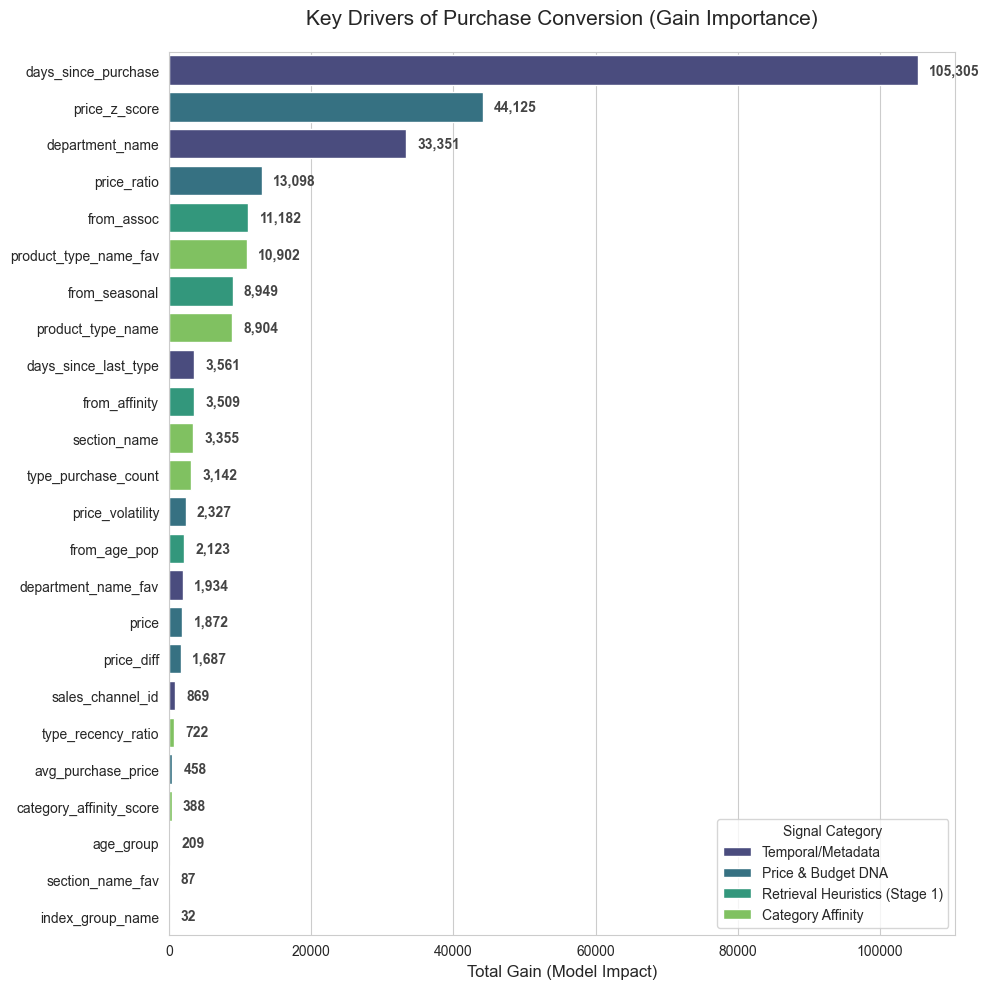

In [35]:
# Filter out features with 0 importance (Most were taken out earlier, but a couple had to stay to make merges work)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
clean_importance = feature_importance[feature_importance['importance'] > 0].copy()

# Categorize features 
def categorize(feat):
    if 'from_' in feat: return 'Retrieval Heuristics (Stage 1)'
    if any(p in feat for p in ['price', 'avg_', 'diff', 'z_score', 'volatility']): return 'Price & Budget DNA'
    if 'days_since' in feat: return 'Temporal/Metadata'
    if any(c in feat for c in ['type', 'dept', 'section', 'affinity', 'match']): return 'Category Affinity'
    return 'Temporal/Metadata'

# Apply categorization and sort by importance
clean_importance['category'] = clean_importance['feature'].apply(categorize)
# Ensure it is sorted correctly for the bar chart
plot_df = clean_importance.sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(10, 10), dpi=100)
sns.set_style("whitegrid")

ax = sns.barplot(
    data=plot_df, 
    x='importance', 
    y='feature', 
    hue='category', 
    dodge=False, 
    palette='viridis'
)

# Precision Labeling
# Calculate a margin based on 1% of the largest bar to keep spaacing consistent
max_width = plot_df['importance'].max()
offset = max_width * 0.015

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + offset,
            p.get_y() + p.get_height()/2,
            f'{width:,.0f}',
            va='center',
            fontsize=10,
            fontweight='bold',
            color='#444444'
        )
    
# Move the legend to the bottom-right for better visibility
plt.legend(title='Signal Category', loc='lower right')
plt.title('Key Drivers of Purchase Conversion (Gain Importance)', fontsize=15, pad=20)
plt.xlabel('Total Gain (Model Impact)', fontsize=12)
plt.ylabel('') # Remove y-label as feature names are self-explanatory

plt.tight_layout()
plt.show()

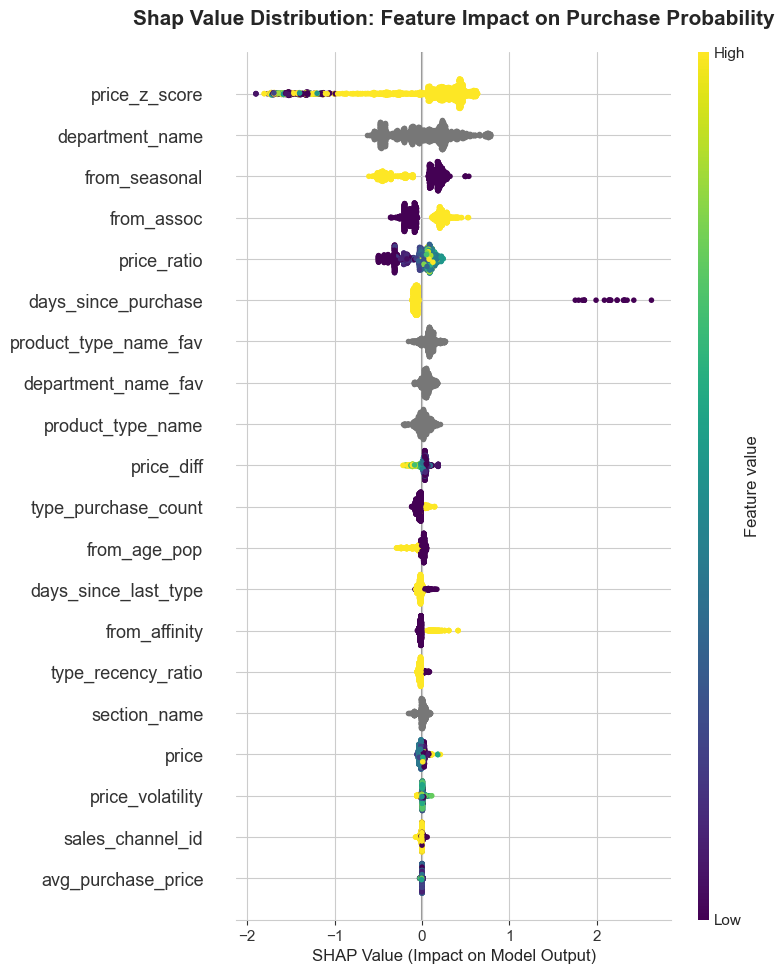

In [36]:
# Calculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_valid.iloc[:2000])

# Plot with a "Beeswarm" distribution
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_valid.iloc[:2000],
    show=False,
    max_display=20,
    cmap='viridis'
)

# Add Context
plt.title('Shap Value Distribution: Feature Impact on Purchase Probability', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=12)
plt.show()

### Key Points:

1. **Dominance of Temporal Decay:** days_since_purchase emerged as the primary driver of the model. This reveals that in fashion, a customer’s current "shopping window" is the strongest predictor of conversion. The model uses this signal to prioritize active users, ensuring that recommendations are fresh and timely.

2. **Price DNA & Budget Guardrails:** The high importance of price_z_score and price_ratio confirms that customers adhere to strict spending brackets. As seen in the SHAP analysis, high price outliers are heavily penalized, ensuring the model acts as a "Budget Guardrail" that keeps recommendations within a user's established spending power.

3. **Cross-Category Style Affinity:** Beyond simple item-to-item matching, the model relies on department_name and product_type_name_fav. This shows the system has successfully moved toward "Style Affinity"—identifying users who shop specifically within certain "sections" (e.g., Divided, Trend, or Premium Quality) rather than just looking at individual product IDs.

4. **Dual-Signal Model Logic (SHAP Insight):** The SHAP beeswarm confirms a sophisticated balance in the ranking logic. While behavioral features like price act as rigorous negative filters (filtering out irrelevant items), the Stage 1 heuristics (e.g., from_seasonal, from_assoc) provide strong positive pushes. This proves the model is acting as both an elevator of high-intent trends and a guardian of user preferences.

### Evaluate the model

In [37]:
# Quick test to debug features

# Get predictions for the validation set
valid_set['pred_score'] = model.predict(X_valid)

# For each customer, see where the 'Target 1' item ranked and sort by customer and then prediction_score
eval_df = valid_set.sort_values(['customer_id', 'pred_score'], ascending=[True, False])

# Simple Metric: Top-12 Hit Rate (Does this actual purchase appear in the top 12 predicted items)
top_12 = eval_df.groupby('customer_id').head(12)
hits = top_12[top_12['target'] == 1].shape[0]
total_possible = valid_set[valid_set['target'] == 1].shape[0]

print(f"Validation Hit Rate @ 12: {hits / total_possible:.2%}")

Validation Hit Rate @ 12: 15.54%


In [38]:
# Real world testing with end-to-end simulation
# Define what we are testing against (Week 0)
test_start_date = week0_data['t_dat'].min()
test_customers = week0_data['customer_id'].unique()[:500] # Limiting to 500 for speed as this is just a quick test

# Run the Candidate Generation
test_candidates = create_samples(
    transactions = train,
    target_start_date = test_start_date,
    age_pop_dict = w1_age_dict,
    top_30 = w1_top_30,
    item_associations = item_associations,
    type_dict = w1_type_dict
)

# Filter out our 500 test subjects
test_candidates = test_candidates[test_candidates['customer_id'].isin(test_customers)]

# Run the Feature Engineering
test_features = build_feature_bundle(test_candidates, week1_data, articles, customers, customer_price_stats=customer_price_stats)

# Align and predict
X_test = test_features[X_train.columns]
test_features['score'] = model.predict(X_test)

# Rank and Evaluate
# Get top 12 per customer based off of the model
top_12_preds = test_features.sort_values(['customer_id', 'score'], ascending=[True, False]).groupby('customer_id').head(12)

# Compare against the actual ground truth (target == 1)
hits = top_12_preds[top_12_preds['target'] == 1].shape[0]
total_possible = week0_data[week0_data['customer_id'].isin(test_customers)].shape[0]

print(f"Simulated Kaggle Hit Rate @ 12: {hits / total_possible:.2%}")

Simulated Kaggle Hit Rate @ 12: 6.50%


## Final submission creation

### Scalable Inference Pipeline
Generating predictions for 1.3 million customers requires efficient memory management

**Batch Processing:** Customers are processed in chunks of 5000 to maintain a low RAM footprint.

**Missing indicator Handling:** For "Cold Start" customers, the model utilizes binary flags (has_price_history) to gracefully degrade from personalization ranking to demographic-based popularity.

In [39]:
GENERATE_SUBMISSION = True # Set to True when I want to create the submission

if GENERATE_SUBMISSION:
    # Pre-calculate data for features
    full_history_set = set(zip(train['customer_id'], train['article_id']))

    full_history_for_sub = recent_data.copy()
    customer_purchase_dict = full_history_for_sub.groupby('customer_id')['article_id'].unique().apply(list).to_dict()
    
    # Batch Configuration
    all_customers = sample_submission['customer_id'].unique()
    batch_size = 5000
    preds_list = []
    article_stats_global = week0_data.groupby('article_id').agg({
        'price': 'median',
        'sales_channel_id': lambda x: x.mode()[0] if not x.mode().empty else 2
    }).reset_index()

    # Create global top 12 as a fallback when customer doesn't have enough history
    global_top_12_list = week0_data['article_id'].value_counts().head(12).index.tolist()
    global_fallback_str = ' '.join([str(x).zfill(10) for x in global_top_12_list])

    # Generate the global and age menus for the submission window
    sub_top_30, sub_age_dict = get_menu(week0_data)

    # Generate the department trends for the submission window
    type_dict_sub = get_type_menu(week0_data, articles)

    # Fast lookup for articles -> product type
    item_to_type_map = articles[['article_id', 'product_type_name']].set_index('article_id')['product_type_name'].to_dict()

    # Pre-Calculate recency master table for build_feature_bundle
    recency_master = recent_data.groupby(['customer_id', 'article_id'])['t_dat'].max().reset_index()
    # Rename columns to avoid confusion during the merge inside the loop
    recency_master.columns = ['customer_id', 'article_id', 't_dat']

    # Pre-calculate type recency for build_feature_bundle
    type_lookup = articles[['article_id', 'product_type_name']]
    history_with_types = recent_data.merge(type_lookup, on='article_id', how='left')
    # Group by customer and type to find the last purchase date
    type_recency = history_with_types.groupby(['customer_id', 'product_type_name'], observed=False)['t_dat'].max().reset_index()
    type_recency.columns = ['customer_id', 'product_type', 'last_type_t_dat']

    # Pre-calculate popularity and affinity to save time
    global_pop = get_popularity(recent_data)
    global_affinity = get_affinity(recent_data, articles)

    global_type_pref = history_with_types.groupby(['customer_id', 'product_type_name'], observed=False).size().reset_index(name='type_purchase_count')
    
    # Remove some dataframes that aren't needed anymore to clear more RAM
    del train
    gc.collect()
    
    print(f"Starting submission generation for {len(all_customers)} customers...")

    # Note: While normally I would try to avoid repeating code, due to the 1.3 million users in this database create_samples cannot be used
    # without running into out-of-memory issues. Batch processing is required which leads to some code having to be re-written
    
    for i in tqdm(range(0, len(all_customers), batch_size)):
        # Get current batch of customers
        batch_customers = all_customers[i:i+batch_size]

        # Batch customers to their age groups
        batch_age_groups = [customer_age_map.get(c, 30) for c in batch_customers]

        age_rows = []
        for c, age in zip(batch_customers, batch_age_groups):
            # Get the top 12 for this specific age group
            age_recs = sub_age_dict.get(age, sub_top_30[:12])
            for a in age_recs:
                age_rows.append({'customer_id': c, 'article_id': a})
        age_part = pd.DataFrame(age_rows)
        age_part['from_age_pop'] = 1

        # Generate the top 15 popular items
        global_pop_15 = sub_top_30[:15]
        popular_part = pd.DataFrame({
            'customer_id': np.repeat(batch_customers, len(global_pop_15)),
            'article_id': np.tile(global_pop_15, len(batch_customers))
        })
        popular_part['from_age_pop'] = 1 # Tag global pop as age_pop source for the model
        
        # Generate the personalized customizations
        personal_rows = []
        for c in batch_customers:
            if c in customer_purchase_dict:
                for a in customer_purchase_dict[c][-10:]:
                    personal_rows.append({'customer_id': c, 'article_id': a})
        personal_part = pd.DataFrame(personal_rows)
        personal_part['from_history'] = 1

        # Associate candidates
        assoc_rows = []
        for c in batch_customers:
            if c in customer_purchase_dict:
                for old_item in customer_purchase_dict[c][-5:]:
                    for p in item_associations.get(old_item, [])[:3]:
                        assoc_rows.append({'customer_id': c, 'article_id': p})
        assoc_part = pd.DataFrame(assoc_rows)
        assoc_part['from_assoc'] = 1

        # Generate the Department affinity candidates
        affinity_rows = []
        for c in batch_customers:
            if c in customer_purchase_dict:
                # Get the last item they bought
                last_bought_id = customer_purchase_dict[c][-1]
                last_type = item_to_type_map.get(last_bought_id)

                if last_type in type_dict_sub:
                    for type_item in type_dict_sub[last_type][:6]:
                        affinity_rows.append({'customer_id': c, 'article_id': type_item})
        affinity_part = pd.DataFrame(affinity_rows)
        if affinity_part.empty:
            affinity_part = pd.DataFrame(columns=['customer_id', 'article_id'])
        affinity_part['from_affinity'] = 1

        # Generate the seasonal candidates
        seasonal_part = pd.DataFrame({
            'customer_id': np.repeat(batch_customers, len(seasonal_pop_ids)),
            'article_id': np.tile(seasonal_pop_ids, len(batch_customers))
        })
        seasonal_part['from_seasonal'] = 1

        # Collect parts, filter out empty ones
        parts = [age_part, popular_part, personal_part, assoc_part, affinity_part, seasonal_part]
        raw_candidates = pd.concat([p for p in parts if not p.empty])
        
        # Fill missing flags with zeroes
        for col in source_flags:
            if col not in raw_candidates.columns:
                raw_candidates[col] = 0  
            raw_candidates[source_flags] = raw_candidates[source_flags].fillna(0).astype(int)
                      
        raw_candidates = raw_candidates.groupby(['customer_id', 'article_id']).max().reset_index()
        
        metadata = articles[['article_id', 'product_type_name', 'department_name', 'index_group_name', 'section_name']]
        raw_candidates = raw_candidates.merge(metadata, on='article_id', how='left')

        # --- THE SPEED FILTER ---
        # Filter the giant global tables down to just the 5000 people in this batch
        # This stops Pandas from scanning millions of rows during the merges
        b_recency = recency_master[recency_master['customer_id'].isin(batch_customers)]
        b_type_recency = type_recency[type_recency['customer_id'].isin(batch_customers)]
        b_affinity = global_affinity[global_affinity['customer_id'].isin(batch_customers)]
        b_type_pref = global_type_pref[global_type_pref['customer_id'].isin(batch_customers)]
        b_price_stats = customer_price_stats[customer_price_stats['customer_id'].isin(batch_customers)]
        b_customers = customers[customers['customer_id'].isin(batch_customers)]
        
        b_df = build_feature_bundle(raw_candidates,
                                    recent_data,
                                    articles,
                                    b_customers,
                                    type_recency_df = b_type_recency,
                                    history_set = full_history_set,
                                    article_stats = article_stats_global,
                                    customer_price_stats = b_price_stats,
                                    recency_df = b_recency,
                                    pop_df = global_pop,
                                    affinity_df = b_affinity,
                                    type_pref_df = b_type_pref
                                   )

        # Make sure all the columns are aligned properly
        b_df_aligned = b_df.reindex(columns=X_train.columns)
        
        # Categorical alignment
        for col in X_train.select_dtypes(include=['category']).columns:
            b_df_aligned[col] = b_df_aligned[col].astype('category').cat.set_categories(X_train[col].cat.categories)
        
        # Make Predictions
        b_df['score'] = model.predict(b_df_aligned)
    
        # Get top 12 for each customers
        top_12 = b_df.sort_values(['customer_id', 'score'], ascending=[True, False]).groupby('customer_id').head(12)
    
        # Format the predictions into the "article_id' string Kaggle wants
        # Article IDs must be strings
        top_12['article_id'] =  top_12['article_id'].astype(str)
    
        # Group by customer and join the 12 IDs into one space-separating string
        batch_preds = top_12.groupby('customer_id')['article_id'].apply(lambda x: ' '.join(x)).reset_index()
        batch_preds.columns = ['customer_id', 'prediction']

        batch_df = pd.DataFrame({'customer_id': batch_customers})
        batch_df = batch_df.merge(batch_preds, on='customer_id', how='left')

        # if top 12 isn't filled out then fill with global top 12
        def fill_and_trim(pred_str):
            if pd.isna(pred_str) or pred_str == "":
                return global_fallback_str
                
            preds = pred_str.split()
            if len(preds) < 12:
                for item in global_top_12_list:
                    item_str = str(item).zfill(10)
                    if item_str not in preds:
                        preds.append(item_str)
                    if len(preds) == 12:
                        break
            return ' '.join(preds[:12])

        batch_df['prediction'] = batch_df['prediction'].apply(fill_and_trim)
        preds_list.append(batch_df)

        # Cleanup
        gc.collect()
    
    # Finalize the CSV
    submission = pd.concat(preds_list)
    # Save the final submission
    submission.to_csv('Recommendation_Submission.csv', index=False)
    print("Submission Saved as Recommendation_Submission.csv")

Starting submission generation for 1371980 customers...


100%|████████████████████████████████████████████████████████████████████████████████| 275/275 [54:27<00:00, 11.88s/it]


Submission Saved as Recommendation_Submission.csv


### Impact Statement

**Final Performance:** Achieved a MAP@12 score of **0.02192**, significantly outperforming the "top-12 popular" baseline. The most predictive features were **Days Since Purchase** and **Price Z-Scores**.
**Days Since Purchase** acted as a critical "Temporal Decay" signal; it allowed the model to distinguish between high-intent, active shoppers and dormant users, effectively pivoting the recommendation strategy from personalized history to broader seasonal trends as the user's data became "stale." This proves that recency and budget alignment are the two most critical factors in fashion conversion.